# SVD Tabanlı Dupe Finder
TF-IDF + Cosine (mevcut) vs **TF-IDF + SVD + Cosine** (yeni) karşılaştırmalı deney

In [1]:
print("Gerekli kütüphaneler içe aktarılıyor.")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

Gerekli kütüphaneler içe aktarılıyor.


In [5]:
print("Veri yükleniyor.")
products_url = "https://raw.githubusercontent.com/bengubal/cosmetic-dupe-finder/refs/heads/main/data/cleaned_products.csv"
df_products = pd.read_csv(products_url)
df = df_products
print(f"Veri seti boyutu: {df.shape}")
df[['product_name', 'brand_name', 'price_usd', 'rating', 'reviews']].head()

Veri yükleniyor.
Veri seti boyutu: (2999, 11)


,product_name,brand_name,price_usd,rating,reviews
0,Baomint Deep Conditioning Treatment,adwoa beauty,39.0,4.5273,311.0
1,Blue Tansy Reparative Mask,adwoa beauty,40.0,4.7581,492.0
2,Baomint Leave In Conditioning Styler,adwoa beauty,26.0,4.3472,144.0
3,Blue Tansy Leave in Conditioning Styler,adwoa beauty,26.0,4.5762,210.0
4,Baomint Moisturizing Shampoo,adwoa beauty,24.0,4.1324,136.0


In [6]:
print("TF-IDF matrisi oluşturuluyor.")
df['text'] = (
    df['clean_ingredients'].fillna('') + ' ' +
    df['product_name'].fillna('')
)

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['text'])

print(f"TF-IDF matris boyutu: {tfidf_matrix.shape}")

TF-IDF matrisi oluşturuluyor.
TF-IDF matris boyutu: (2999, 5000)


## Yöntem 1: TF-IDF + Cosine Similarity (Baseline)

In [7]:
print("Yöntem 1: TF-IDF + Cosine Similarity hesaplanıyor (baseline).")
cosine_sim_tfidf = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"Cosine similarity matris boyutu: {cosine_sim_tfidf.shape}")

Yöntem 1: TF-IDF + Cosine Similarity hesaplanıyor (baseline).
Cosine similarity matris boyutu: (2999, 2999)


## Yöntem 2: TF-IDF + SVD + Cosine Similarity

In [8]:
print("Yöntem 2: TruncatedSVD ile boyut indirgeme yapılıyor.")
# n_components: kaç latent boyut? 100-300 arası iyi
svd = TruncatedSVD(n_components=100, random_state=42)
svd_matrix = svd.fit_transform(tfidf_matrix)

explained = svd.explained_variance_ratio_.sum()
print(f"SVD matris boyutu: {svd_matrix.shape}")
print(f"Açıklanan varyans oranı: %{explained*100:.1f}")

Yöntem 2: TruncatedSVD ile boyut indirgeme yapılıyor.
SVD matris boyutu: (2999, 100)
Açıklanan varyans oranı: %38.4


Açıklanan varyans oranı grafiği çiziliyor.


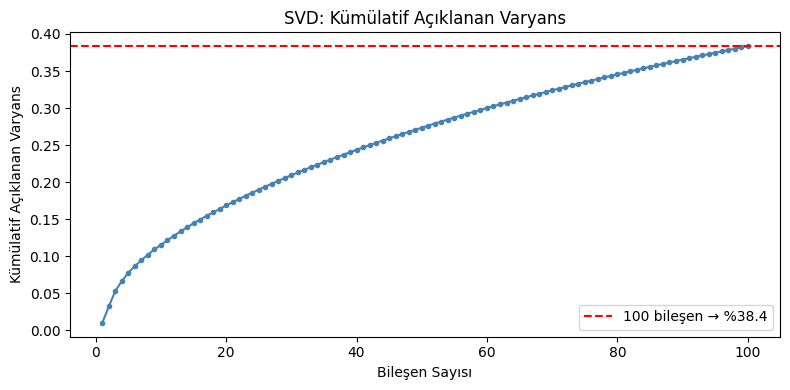

In [9]:
print("Açıklanan varyans oranı grafiği çiziliyor.")
cumvar = np.cumsum(svd.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=3, color='steelblue')
plt.axhline(y=explained, color='red', linestyle='--', label=f'100 bileşen → %{explained*100:.1f}')
plt.xlabel('Bileşen Sayısı')
plt.ylabel('Kümülatif Açıklanan Varyans')
plt.title('SVD: Kümülatif Açıklanan Varyans')
plt.legend()
plt.tight_layout()
plt.savefig('svd_explained_variance.png', dpi=150)
plt.show()

In [10]:
print("SVD uzayında cosine similarity hesaplanıyor.")
cosine_sim_svd = cosine_similarity(svd_matrix, svd_matrix)
print(f"SVD Cosine similarity matris boyutu: {cosine_sim_svd.shape}")

SVD uzayında cosine similarity hesaplanıyor.
SVD Cosine similarity matris boyutu: (2999, 2999)


## Dupe Finder Fonksiyonu (Re-ranking ile)

In [17]:
print("Fiyat ve rating re-ranking içeren dupe finder fonksiyonu tanımlanıyor.")

def find_dupes(product_id, sim_matrix, top_n=5, price_weight=0.4, rating_weight=0.6):
    """
    Verilen ürün için dupe'ları bulur ve fiyat + rating'e göre sıralar.

    Parametreler:
        product_id    : hedef ürün ID'si
        sim_matrix    : cosine_sim_tfidf veya cosine_sim_svd
        top_n         : kaç dupe döndürülsün
        price_weight  : fiyat ucuzluğunun ağırlığı (0-1)
        rating_weight : rating yüksekliğinin ağırlığı (0-1)
    """
    mask = df['product_id'] == product_id
    if not mask.any():
        print(f"Ürün bulunamadı: {product_id}")
        return None

    idx = df[mask].index[0]
    target_price = df.loc[idx, 'price_usd']
    target_brand = df.loc[idx, 'brand_name'].lower().strip()

    # Benzerlik skorlarını al, kendini çıkar
    sim_scores = list(enumerate(sim_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n*20]  # geniş aday havuzu

    candidate_idx = [i[0] for i in sim_scores]
    candidate_sim = [i[1] for i in sim_scores]

    candidates = df.iloc[candidate_idx].copy()
    candidates['ingredient_similarity'] = candidate_sim

    # Filtreler: ucuz + farklı marka
    # Filtreler: hedef fiyatın %50'sinden ucuz + farklı marka
    candidates = candidates[
        (candidates['price_usd'] < target_price * 0.5) &
        (candidates['brand_name'].str.lower().str.strip() != target_brand)
    ]

    if candidates.empty:
        print("Uygun dupe bulunamadı.")
        return None

    # Re-ranking: fiyat + rating skoru
    scaler = MinMaxScaler()
    candidates['price_score']  = 1 - scaler.fit_transform(candidates[['price_usd']])
    candidates['rating_score'] = scaler.fit_transform(candidates[['rating']])
    candidates['final_score']  = (
        price_weight  * candidates['price_score'] +
        rating_weight * candidates['rating_score']
    )

    result = candidates.sort_values('final_score', ascending=False).head(top_n)

    return result[[
        'product_id', 'product_name', 'brand_name',
        'price_usd', 'rating', 'reviews',
        'ingredient_similarity', 'price_score', 'rating_score', 'final_score'
    ]].reset_index(drop=True)

Fiyat ve rating re-ranking içeren dupe finder fonksiyonu tanımlanıyor.


## Karşılaştırmalı Deney

In [18]:
print("Karşılaştırmalı deney: pahalı bir ürün seçiliyor.")

# En pahalı ürünlerden birini seç
sample = df.nlargest(10, 'price_usd').iloc[0]
sample_id = sample['product_id']

print("=" * 50)
print("HEdef ÜRÜN:")
print(f"  İsim   : {sample['product_name']}")
print(f"  Marka  : {sample['brand_name']}")
print(f"  Fiyat  : ${sample['price_usd']}")
print(f"  Rating : {sample['rating']}")
print("=" * 50)

Karşılaştırmalı deney: pahalı bir ürün seçiliyor.
HEdef ÜRÜN:
  İsim   : The Concentrate Serum
  Marka  : La Mer
  Fiyat  : $425.0
  Rating : 4.5187


In [19]:
print("Yöntem 1 (TF-IDF + Cosine) sonuçları:")
results_tfidf = find_dupes(sample_id, cosine_sim_tfidf)
print(results_tfidf.to_string(index=False))

Yöntem 1 (TF-IDF + Cosine) sonuçları:
product_id                                                        product_name        brand_name  price_usd  rating  reviews  ingredient_similarity  price_score  rating_score  final_score
   P476571 Turbo Body Lotion Energizing Gel Moisturizer with Eucalyptus & Aloe        Jack Black      38.00  5.0000      1.0               0.260846     0.818182      1.000000     0.927273
   P504004                             Heavenly Hydration Pre-Shampoo Hair Oil        BondiBoost      29.99  4.9109    101.0               0.222001     0.874196      0.932937     0.909440
   P502024                                 Curl Conditioning Hair Oil-In-Cream         Curlsmith      12.00  4.7317     41.0               0.264243     1.000000      0.798058     0.878835
   P479832                                      Bond-Building Repair Treatment Bumble and bumble      35.00  4.8505    368.0               0.235892     0.839161      0.887476     0.868150
   P504073            

In [20]:
print("Yöntem 2 (TF-IDF + SVD + Cosine) sonuçları:")
results_svd = find_dupes(sample_id, cosine_sim_svd)
print(results_svd.to_string(index=False))

Yöntem 2 (TF-IDF + SVD + Cosine) sonuçları:
product_id                                                        product_name        brand_name  price_usd  rating  reviews  ingredient_similarity  price_score  rating_score  final_score
   P476571 Turbo Body Lotion Energizing Gel Moisturizer with Eucalyptus & Aloe        Jack Black       38.0  5.0000      1.0               0.598580     0.818182      1.000000     0.927273
   P502024                                 Curl Conditioning Hair Oil-In-Cream         Curlsmith       12.0  4.7317     41.0               0.395924     1.000000      0.789188     0.873513
   P479832                                      Bond-Building Repair Treatment Bumble and bumble       35.0  4.8505    368.0               0.433974     0.839161      0.882533     0.865184
   P504199                               Plankton + PHAFlower Acid Algae Serum              MARA       74.0  4.8846     52.0               0.401511     0.566434      0.909327     0.772169
   P481821      

## Karşılaştırma Görseli

İki yöntemin karşılaştırma grafiği çiziliyor.


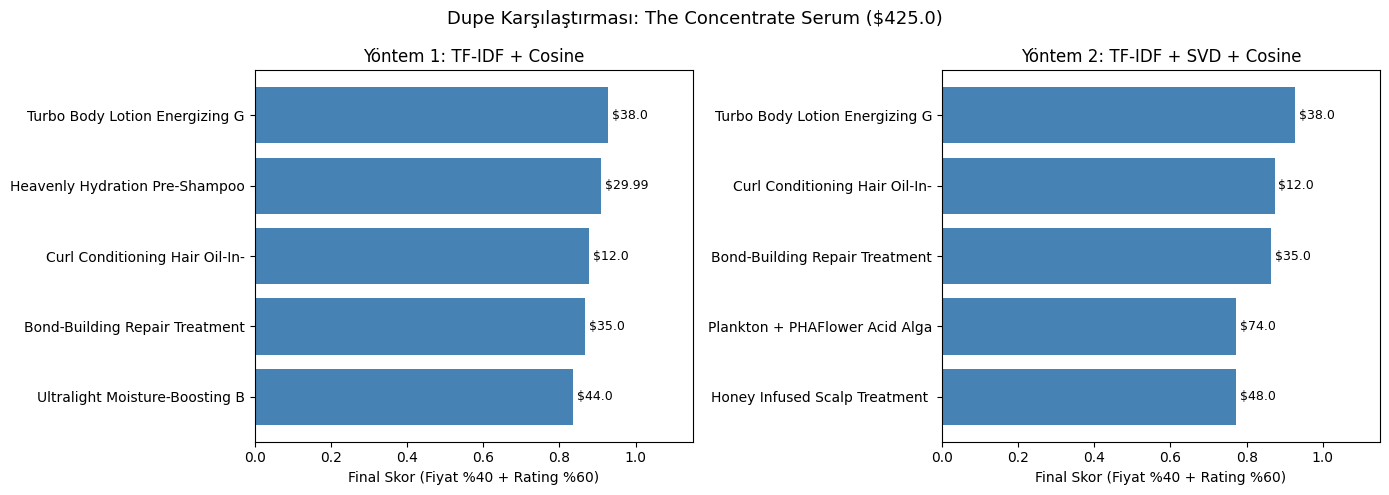

In [21]:
print("İki yöntemin karşılaştırma grafiği çiziliyor.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Dupe Karşılaştırması: {sample["product_name"]} (${sample["price_usd"]})', fontsize=13)

for ax, (res, title) in zip(axes, [
    (results_tfidf, 'Yöntem 1: TF-IDF + Cosine'),
    (results_svd,   'Yöntem 2: TF-IDF + SVD + Cosine')
]):
    bars = ax.barh(
        res['product_name'].str[:30],
        res['final_score'],
        color='steelblue'
    )
    # Fiyat etiketleri
    for bar, price in zip(bars, res['price_usd']):
        ax.text(
            bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'${price}', va='center', fontsize=9
        )
    ax.set_xlabel('Final Skor (Fiyat %40 + Rating %60)')
    ax.set_title(title)
    ax.set_xlim(0, 1.15)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('dupe_comparison.png', dpi=150)
plt.show()

In [22]:
print("İki yöntemin ortalama ingredient_similarity değerleri karşılaştırılıyor.")

comparison = pd.DataFrame({
    'Metrik': ['Ort. Benzerlik', 'Ort. Fiyat ($)', 'Ort. Rating', 'Ort. Final Skor'],
    'TF-IDF + Cosine': [
        results_tfidf['ingredient_similarity'].mean(),
        results_tfidf['price_usd'].mean(),
        results_tfidf['rating'].mean(),
        results_tfidf['final_score'].mean()
    ],
    'TF-IDF + SVD + Cosine': [
        results_svd['ingredient_similarity'].mean(),
        results_svd['price_usd'].mean(),
        results_svd['rating'].mean(),
        results_svd['final_score'].mean()
    ]
})
print(comparison.to_string(index=False))

İki yöntemin ortalama ingredient_similarity değerleri karşılaştırılıyor.
         Metrik  TF-IDF + Cosine  TF-IDF + SVD + Cosine
 Ort. Benzerlik         0.243609               0.457244
 Ort. Fiyat ($)        31.798000              41.400000
    Ort. Rating         4.865820               4.839180
Ort. Final Skor         0.884025               0.841945
